# Predicting Financial Stress Events with the VSRI.

In [ ]:
SEED = 23
# --- ENV FIRST ---
import os
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
# --- IMPORTS ---
import random
import numpy as np
import tensorflow as tf
# --- TF CONFIG ---
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.set_visible_devices([], 'GPU')
# --- SEEDS ---
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
# --- RESET ---
tf.keras.backend.clear_session()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix, accuracy_score, roc_curve, precision_score
import itertools
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
try:
  import keras_tuner as kt
except:
  !pip install keras-tuner
  import keras_tuner as kt
from google.colab import files
from google.colab import drive
import pandas as pd
import io
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

In [ ]:
def import_data(file_path):
  try:
    drive.mount('/content/drive', force_remount=True)
    # Check if file exists
    if os.path.exists(file_path):
      df = pd.read_parquet(file_path)
      print(f"Loaded dataframe from Drive ({file_path})")
    else:
      raise FileNotFoundError(f"File not found at {file_path}")

  except Exception as e:
    print(f"Drive not available or file missing: {e}")
    print("Please upload dataframe manually.")
    uploaded = files.upload()

    # Automatically read the uploaded file
    file_name = list(uploaded.keys())[0]  # pick the first uploaded file
    try:
      df = pd.read_parquet(io.BytesIO(uploaded[file_name]))
    except:
      print("Wrong file extension. Parquet file required.")
    print(f"Loaded {file_name} from manual upload.")
    return df

In [ ]:
file_path = "..."
vsri = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving vsri.parquet to vsri (1).parquet
Loaded vsri (1).parquet from manual upload.


In [ ]:
df_sse = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving df_sse.parquet to df_sse (1).parquet
Loaded df_sse (1).parquet from manual upload.


In [ ]:
# build a dataframe with the VSRI (predictor) and the Systemic Stress Events variable (target)
df_model = pd.concat([vsri, df_sse['systemic_stress_event']], axis=1, join='inner').dropna()

In [ ]:
df_model.shape

(2285, 2)

In [ ]:
# split data in training and test set and apply purging
split_date = "2024-03-31"
purge = 20
train = df_model.loc[:split_date].iloc[:-purge]
test = df_model[df_model.index > split_date]
X_train = train[["VSRI"]]
y_train = train["systemic_stress_event"]
X_test  = test[["VSRI"]]
y_test  = test["systemic_stress_event"]

In [ ]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1789, 1) (1789,) (476, 1) (476,)


In [ ]:
y_train.value_counts()

,count
systemic_stress_event,
0,1663
1,126


In [ ]:
y_test.value_counts()

,count
systemic_stress_event,
0,452
1,24


In [ ]:
def train_classifier(model, X_train, y_train, X_test, y_test, X_val=False, y_val=False, threshold=0.5, early_stopping=False):
  is_keras = hasattr(model, "fit") and hasattr(model, "predict") and not hasattr(model, "predict_proba")
  if is_keras:
    if early_stopping:
      model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, class_weight=class_weight, validation_data=(X_val, y_val), shuffle=False, callbacks=[combined_metric, es])
    else:
      model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, class_weight=class_weight, validation_data=(X_val, y_val), shuffle=False)
    y_score = model.predict(X_test).ravel()
    y_pred = (y_score >= threshold).astype(int)
  else:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

  # Output Following Metrics:
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_score)
  cm = confusion_matrix(y_test, y_pred)

  return recall, f1, roc_auc, cm, y_score, y_pred

## 5.1. Logistic Regression.

In [ ]:
lr_model = LogisticRegression(class_weight="balanced")
lr_results = train_classifier(lr_model, X_train, y_train, X_test, y_test)

In [ ]:
lr_recall, lr_f1, lr_roc_auc, lr_cm, lr_probs, lr_preds = lr_results

In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  print(cm)
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes)#, rotation=45)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

Confusion matrix, without normalization
[[132 320]
 [  6  18]]


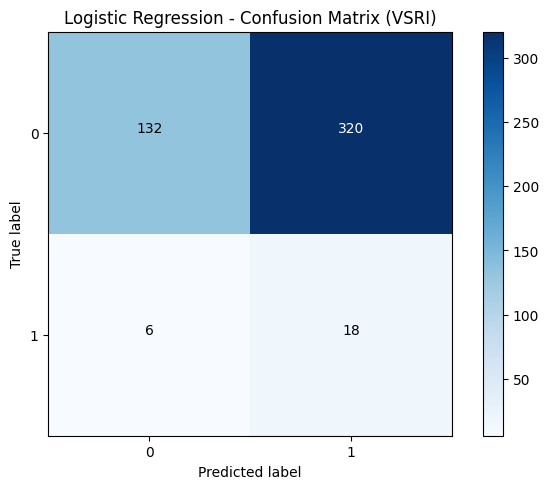

In [ ]:
plot_confusion_matrix(cm=lr_cm, classes=[0,1], normalize= False,  title='Logistic Regression - Confusion Matrix (VSRI)')

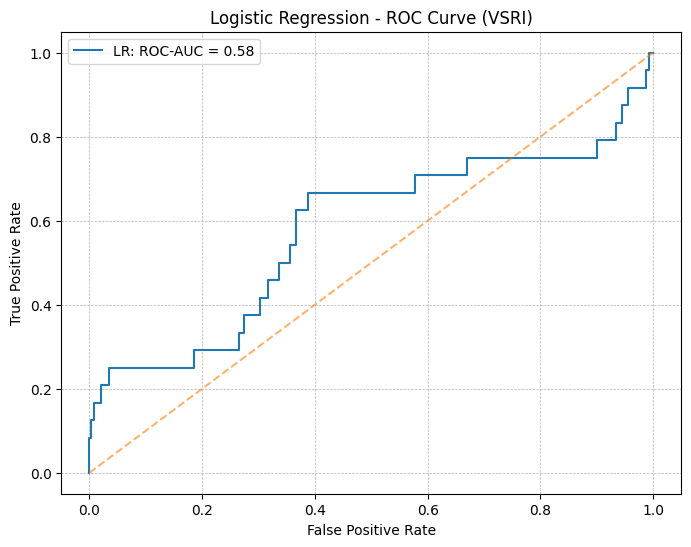

In [ ]:
fpr, tpr, thr = roc_curve(y_test, lr_probs)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"LR: ROC-AUC = {lr_roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve (VSRI)")
plt.legend()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

In [ ]:
lr_results = {'Recall': lr_recall, 'F1-Score': lr_f1, 'ROC-AUC': lr_roc_auc}
lr_results_df = pd.DataFrame(lr_results, index=['Logistic Regression (VSRI)'])
lr_results_df

,Recall,F1-Score,ROC-AUC
Logistic Regression (VSRI),0.75,0.099448,0.575498


## 5.2. Support Vector Machines.

In [ ]:
svm_model = SVC(C=0.5, kernel='rbf', probability=True, class_weight="balanced")
svm_results = train_classifier(svm_model, X_train, y_train, X_test, y_test)

In [ ]:
svm_recall, svm_f1, svm_roc_auc, svm_cm, svm_probs, svm_preds = svm_results

Confusion matrix, without normalization
[[141 311]
 [  2  22]]


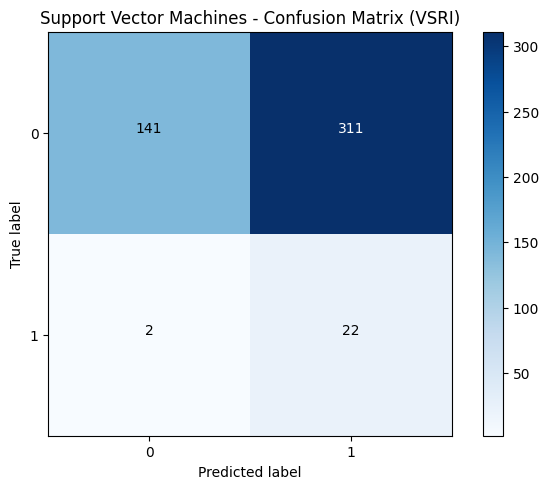

In [ ]:
plot_confusion_matrix(cm=svm_cm, classes=[0,1], normalize= False,  title='Support Vector Machines - Confusion Matrix (VSRI)')

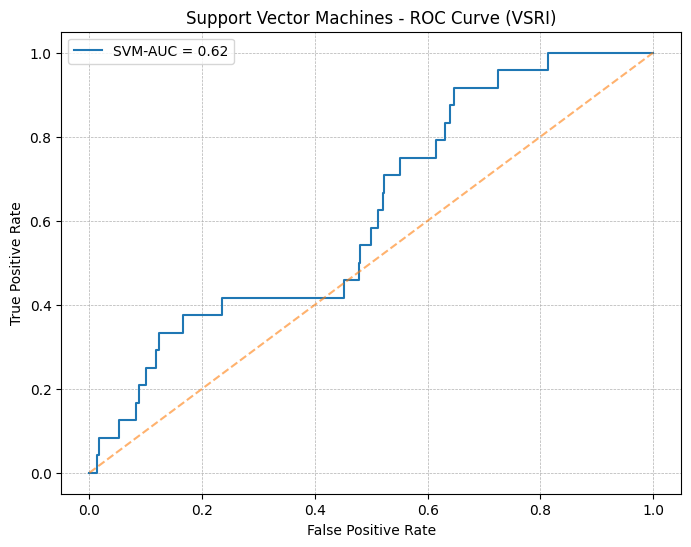

In [ ]:
fpr, tpr, thr = roc_curve(y_test, svm_probs)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"SVM-AUC = {svm_roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Support Vector Machines - ROC Curve (VSRI)")
plt.legend()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

In [ ]:
svm_results_df = pd.DataFrame({'Recall': svm_recall, 'F1-Score': svm_f1, 'ROC-AUC': svm_roc_auc},index=['Support Vector Machines (VSRI)'])
#ml_results = pd.concat([lr_results, svm_results_df])
svm_results_df

,Recall,F1-Score,ROC-AUC
Support Vector Machines (VSRI),0.916667,0.123249,0.621681


## 5.3. Long Short-Term Memory (LSTM) Networks.

In [ ]:
vsri_lstm = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving vsri_lstm.parquet to vsri_lstm (1).parquet
Loaded vsri_lstm (1).parquet from manual upload.


In [ ]:
# build a dataframe with the VSRI_LSTM and the Systemic Stress Events variable (target)
df_model_lstm = pd.concat([vsri_lstm, df_sse['systemic_stress_event']], axis=1, join='inner').dropna()

In [ ]:
df_model_lstm.shape

(2285, 2)

In [ ]:
# split data in training and test set and apply purging
split_date = "2024-03-31"
purge = 20
train = df_model_lstm.loc[:split_date].iloc[:-purge]
test = df_model_lstm[df_model_lstm.index > split_date]
X_train = train[["VSRI_LSTM"]]
y_train = train["systemic_stress_event"]
X_test  = test[["VSRI_LSTM"]]
y_test  = test["systemic_stress_event"]

In [ ]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1789, 1) (1789,) (476, 1) (476,)


In [ ]:
timesteps = 60
split_idx = pd.Timestamp("2023-03-01")
X_train_lstm = X_train[X_train.index < split_idx].iloc[:-purge]
y_train_lstm = y_train[y_train.index < split_idx].iloc[:-purge]
X_val_lstm = X_train.loc[split_idx:]
y_val_lstm = y_train.loc[split_idx:]

X_train_values = X_train_lstm.values
y_train_values = y_train_lstm.values
X_test_values = X_test.values
y_test_values = y_test.values
X_val_values = X_val_lstm.values
y_val_values = y_val_lstm.values
X_train_seq = []
y_train_seq = []
X_test_seq = []
y_test_seq = []
X_val_seq = []
y_val_seq = []

for i in range(timesteps, len(X_train_values)):
  X_train_seq.append(X_train_values[i - timesteps:i])
  y_train_seq.append(y_train_values[i])
for i in range(timesteps, len(X_test_values)):
  X_test_seq.append(X_test_values[i - timesteps:i])
  y_test_seq.append(y_test_values[i])
for i in range(timesteps, len(X_val_values)):
  X_val_seq.append(X_val_values[i - timesteps:i])
  y_val_seq.append(y_val_values[i])

X_train_seq = np.array(X_train_seq)
y_train_seq = np.array(y_train_seq)
X_test_seq = np.array(X_test_seq)
y_test_seq = np.array(y_test_seq)
X_val_seq = np.array(X_val_seq)
y_val_seq = np.array(y_val_seq)

In [ ]:
print(X_train_seq.shape,
      y_train_seq.shape,
      X_val_seq.shape,
      y_val_seq.shape,
      X_test_seq.shape,
      y_test_seq.shape)

(1457, 60, 1) (1457,) (192, 60, 1) (192,) (416, 60, 1) (416,)


In [ ]:
np.unique(y_train_seq, return_counts=True)

(array([0, 1]), array([1341,  116]))

In [ ]:
np.unique(y_val_seq, return_counts=True)

(array([0, 1]), array([182,  10]))

In [ ]:
np.unique(y_test_seq, return_counts=True)

(array([0, 1]), array([392,  24]))

In [ ]:
tf.keras.backend.clear_session()
input_shape = X_train_seq.shape[1:]  # (60, num_features)
lstm_model = keras.Sequential()
lstm_model.add(layers.LSTM(128, return_sequences=True, input_shape=input_shape))
lstm_model.add(layers.Dropout(0.5))
lstm_model.add(layers.LSTM(128, return_sequences=True))
lstm_model.add(layers.LSTM(16, return_sequences=True))
lstm_model.add(layers.LSTM(8, return_sequences=True))
lstm_model.add(layers.Dropout(0.3))
lstm_model.add(layers.LSTM(8, return_sequences=False))
lstm_model.add(layers.Dropout(0.3))
# Dense layers
lstm_model.add(layers.Dense(16, activation="relu"))
lstm_model.add(layers.Dense(1, activation="sigmoid"))
# Compile
lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                   loss="binary_crossentropy",
                   metrics=[keras.metrics.AUC(name="pr_auc", curve="PR"),
                            keras.metrics.AUC(name="roc_auc", curve="ROC"),
                            tf.keras.metrics.Recall(name="recall"),
                            tf.keras.metrics.Precision(name="precision")])

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 16)         │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 8)          │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,929 (816.13 KB)

 Trainable params: 208,929 (816.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class CombinedMetric(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    logs = logs or {}
    recall = logs.get("val_recall", 0)
    pr_auc = logs.get("val_pr_auc", 0)
    logs["val_combined"] = 0.3 * recall + 0.7 * pr_auc

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
combined_metric = CombinedMetric()
es = tf.keras.callbacks.EarlyStopping(monitor="val_combined", mode="max", patience=50, restore_best_weights=True, verbose=1)
classes = np.unique(y_train_seq)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_seq)
class_weight = dict(zip(classes, weights))
epochs=200
batch_size=32

lstm_results = train_classifier(lstm_model, X_train_seq, y_train_seq, X_test_seq, y_test_seq, X_val=X_val_seq, y_val=y_val_seq, early_stopping=True)

Epoch 1/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 223ms/step - loss: 0.6937 - pr_auc: 0.0747 - precision: 0.0399 - recall: 0.0948 - roc_auc: 0.4738 - val_loss: 0.6922 - val_pr_auc: 0.0521 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.5000 - val_combined: 0.0365
Epoch 2/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - loss: 0.6929 - pr_auc: 0.0822 - precision: 0.0787 - recall: 0.2069 - roc_auc: 0.5206 - val_loss: 0.6934 - val_pr_auc: 0.0521 - val_precision: 0.0521 - val_recall: 1.0000 - val_roc_auc: 0.5000 - val_combined: 0.3365
Epoch 3/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 197ms/step - loss: 0.6935 - pr_auc: 0.0747 - precision: 0.0660 - recall: 0.3448 - roc_auc: 0.4733 - val_loss: 0.6937 - val_pr_auc: 0.0521 - val_precision: 0.0521 - val_recall: 1.0000 - val_roc_auc: 0.5000 - val_combined: 0.3365
Epoch 4/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - loss: 0.6937 - pr_auc: 0.0704 - precision: 0.0692 - recall: 0.2672 - roc_auc: 0.4479 - val_loss: 0.6918 - val_pr_auc: 0.0521 -

In [ ]:
lstm_recall, lstm_f1, lstm_roc_auc, lstm_cm, lstm_probs, lstm_preds = lstm_results

Confusion matrix, without normalization
[[239 153]
 [  6  18]]


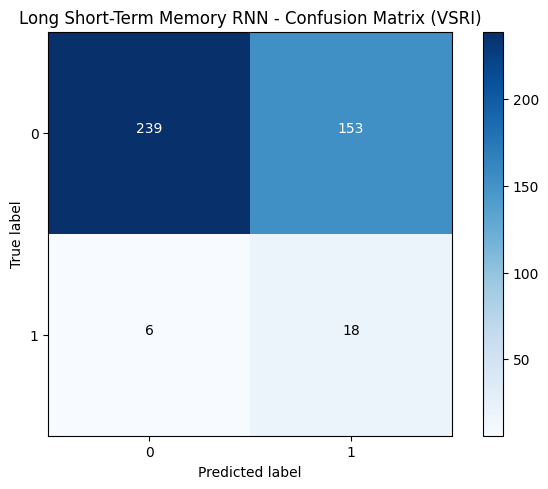

In [ ]:
plot_confusion_matrix(cm=lstm_cm, classes=[0,1], normalize= False,  title='Long Short-Term Memory RNN - Confusion Matrix (VSRI)')

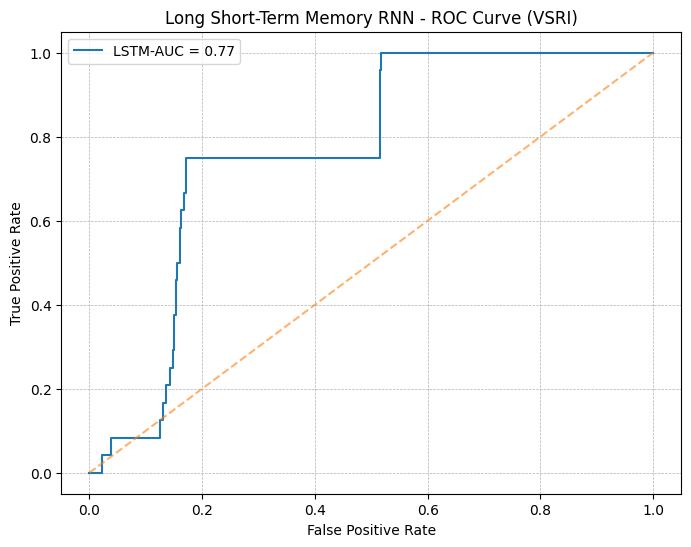

In [ ]:
fpr, tpr, thr = roc_curve(y_test_seq, lstm_probs)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"LSTM-AUC = {lstm_roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Long Short-Term Memory RNN - ROC Curve (VSRI)")
plt.legend()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

In [ ]:
lstm_results_df = pd.DataFrame({'Recall': lstm_recall, 'F1-Score': lstm_f1, 'ROC-AUC': lstm_roc_auc},index=['Long Short-Term Memory RNN (VSRI)'])
lstm_results_df

,Recall,F1-Score,ROC-AUC
Long Short-Term Memory RNN (VSRI),0.75,0.184615,0.766901


In [ ]:
ml_results = pd.concat([lr_results_df.round(2), svm_results_df.round(2), lstm_results_df.round(2)])
ml_results

,Recall,F1-Score,ROC-AUC
Logistic Regression (VSRI),0.75,0.10,0.58
Support Vector Machines (VSRI),0.92,0.12,0.62
Long Short-Term Memory RNN (VSRI),0.75,0.18,0.77


```python
ml_results.to_csv("ml_results.csv", index=True)
files.download("ml_results.csv")
ml_results.to_parquet("ml_results.parquet", index=True)
files.download("ml_results.parquet")
```